# OCR_ICPR - Track Inference Viewer
Notebook nay giup ban chay inference theo tung track va xem truc tiep cac frame cung ket qua OCR.

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd()
BASELINE_DIR = PROJECT_ROOT / 'baseline'

if str(BASELINE_DIR) not in sys.path:
    sys.path.insert(0, str(BASELINE_DIR))

from inference import load_model
from transforms import get_val_transforms
from postprocess import batch_beam_search_decode, validate_plate_format
from config import Config

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {Config.DEVICE}')

/home/nhannv/.conda/envs/ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /hdd3/nhannv/Hello/TrinhHao/OCR_ICPR
Device: cuda


In [19]:
# --- Config ---
MODEL_PATH = PROJECT_ROOT / 'best_models' / 'best_model_phase3_scratch.pth'
TEST_DIR = PROJECT_ROOT / 'dataset' / 'Scenario-A' / 'Brazilian'
PREFERRED_TRACK_ID = 'track_07403'  # Se fallback neu khong ton tai
BEAM_WIDTH = 10

assert MODEL_PATH.exists(), f'Khong tim thay model: {MODEL_PATH}'
assert TEST_DIR.exists(), f'Khong tim thay thu muc test: {TEST_DIR}'

all_tracks = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name.startswith('track_')])
assert len(all_tracks) > 0, f'Khong co track nao trong: {TEST_DIR}'

if PREFERRED_TRACK_ID in all_tracks:
    TRACK_ID = PREFERRED_TRACK_ID
else:
    TRACK_ID = all_tracks[0]
    print(f'{PREFERRED_TRACK_ID} khong ton tai, dung track dau tien: {TRACK_ID}')

print(f'Model: {MODEL_PATH}')
print(f'Test dir: {TEST_DIR}')
print(f'Using track: {TRACK_ID}')

Model: /hdd3/nhannv/Hello/TrinhHao/OCR_ICPR/best_models/best_model_phase3_scratch.pth
Test dir: /hdd3/nhannv/Hello/TrinhHao/OCR_ICPR/dataset/Scenario-A/Brazilian
Using track: track_07403


In [20]:
device = Config.DEVICE
model = load_model(str(MODEL_PATH), device)
transform = get_val_transforms()

def load_track_images(track_dir: Path, num_frames: int = 5):
    # Ho tro nhieu dinh dang file LR trong dataset (.png, .jpg, .jpeg)
    candidates = []
    for ext in ('png', 'jpg', 'jpeg', 'PNG', 'JPG', 'JPEG'):
        candidates.extend(sorted(track_dir.glob(f'lr-*.{ext}')))

    frame_paths = sorted(set(candidates))[:num_frames]
    if len(frame_paths) < num_frames:
        raise FileNotFoundError(
            f'Khong du {num_frames} frame LR trong {track_dir}. Tim thay: {frame_paths}'
        )

    pil_images = [Image.open(p).convert('RGB') for p in frame_paths]
    np_images = [np.array(img) for img in pil_images]
    tensor_images = [transform(image=img)['image'] for img in np_images]
    stacked = torch.stack(tensor_images, dim=0)  # [5, C, H, W]
    return frame_paths, pil_images, stacked

@torch.no_grad()
def infer_single_track(track_id: str):
    track_dir = TEST_DIR / track_id
    frame_paths, pil_images, stacked = load_track_images(track_dir)

    batch = stacked.unsqueeze(0).to(device)  # [1, 5, C, H, W]
    outputs = model(batch)                  # [1, T, C] log-probs

    decoded, confidences = batch_beam_search_decode(
        outputs,
        Config.IDX2CHAR,
        beam_width=BEAM_WIDTH,
        blank=0,
        format_bonus_weight=1.5,
    )

    text = decoded[0]
    conf = float(confidences[0])
    is_valid, plate_type = validate_plate_format(text)

    return {
        'track_id': track_id,
        'frame_paths': frame_paths,
        'pil_images': pil_images,
        'text': text,
        'confidence': conf,
        'valid_format': is_valid,
        'plate_type': plate_type,
    }


📦 Loading model from: /hdd3/nhannv/Hello/TrinhHao/OCR_ICPR/best_models/best_model_phase3_scratch.pth
   Model Type: Phase3Recognizer
   STN: True
   Backbone: ResNet34
   Loading Phase 3 model (BiLSTM)...
   ✅ Model loaded successfully
   Epoch: 48
   Accuracy: 77.55%
   CER: 0.0583


In [21]:
result = infer_single_track(TRACK_ID)
print(f"Track: {result['track_id']}")
print(f"Prediction: {result['text']}")
print(f"Confidence: {result['confidence']:.4f}")
print(f"Valid format: {result['valid_format']} ({result['plate_type']})")

Track: track_07403
Prediction: BCD7792
Confidence: 0.9835
Valid format: True (brazilian_old)


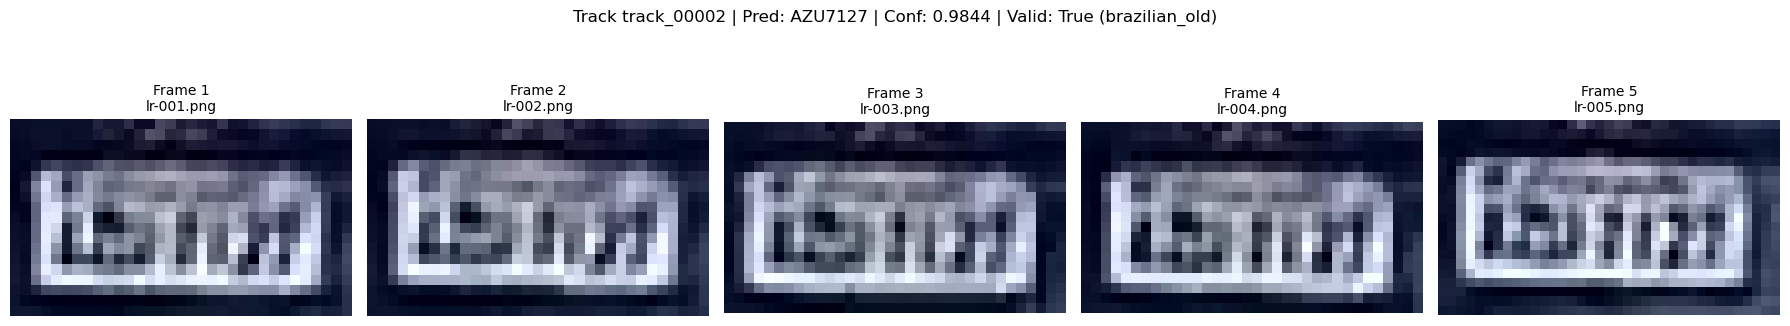

In [18]:
fig, axes = plt.subplots(1, len(result['pil_images']), figsize=(18, 4))
for i, (ax, img, p) in enumerate(zip(axes, result['pil_images'], result['frame_paths'])):
    ax.imshow(img)
    ax.set_title(f'Frame {i+1}\n{p.name}', fontsize=10)
    ax.axis('off')

title = (
    f"Track {result['track_id']} | Pred: {result['text']} | "
    f"Conf: {result['confidence']:.4f} | Valid: {result['valid_format']} ({result['plate_type']})"
)
plt.suptitle(title, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Optional: doi track nhanh
# TRACK_ID = 'track_10005'
# result = infer_single_track(TRACK_ID)
# print(result['text'], result['confidence'])